In [30]:
import pandas as pd
import swspy
import obspy
import matplotlib.pyplot as plt
from obspy import UTCDateTime

In [180]:
# Load in catalog with date_time for pulling IRIS waveforms
sample_catalog = pd.read_csv('../data/catalog_with_geometry_filtered.csv')

In [181]:
# Import miniSEED file
st = obspy.read("sample_waveforms.mseed")

st.filter("highpass", freq=10.0) 

249 Trace(s) in Stream:

OO.AXCC1..HHE | 2015-01-01T05:14:20.785000Z - 2015-01-01T05:14:35.780000Z | 200.0 Hz, 3000 samples
...
(247 other traces)
...
OO.AXEC2..HHZ | 2015-01-01T21:50:22.240000Z - 2015-01-01T21:50:37.240000Z | 200.0 Hz, 3001 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]

In [182]:
st_0 = st.select(station='AXAS1')
st_0 = st_0.trim(starttime=st[0].stats.starttime)
st_0 = st_0.trim(endtime=st_0[0].stats.starttime + 15)

In [183]:
st_0.remove(st_0[1])

5 Trace(s) in Stream:
OO.AXAS1..EHE | 2015-01-01T05:14:20.785000Z - 2015-01-01T05:14:35.780000Z | 200.0 Hz, 3000 samples
OO.AXAS1..EHN | 2015-01-01T05:14:20.785000Z - 2015-01-01T05:14:35.780000Z | 200.0 Hz, 3000 samples
OO.AXAS1..EHN | 2015-01-01T05:14:20.785000Z - 2015-01-01T05:14:35.780000Z | 200.0 Hz, 3000 samples
OO.AXAS1..EHZ | 2015-01-01T05:14:20.785000Z - 2015-01-01T05:14:35.780000Z | 200.0 Hz, 3000 samples
OO.AXAS1..EHZ | 2015-01-01T05:14:20.785000Z - 2015-01-01T05:14:35.780000Z | 200.0 Hz, 3000 samples

In [184]:
st_0.remove(st_0[2])

4 Trace(s) in Stream:
OO.AXAS1..EHE | 2015-01-01T05:14:20.785000Z - 2015-01-01T05:14:35.780000Z | 200.0 Hz, 3000 samples
OO.AXAS1..EHN | 2015-01-01T05:14:20.785000Z - 2015-01-01T05:14:35.780000Z | 200.0 Hz, 3000 samples
OO.AXAS1..EHZ | 2015-01-01T05:14:20.785000Z - 2015-01-01T05:14:35.780000Z | 200.0 Hz, 3000 samples
OO.AXAS1..EHZ | 2015-01-01T05:14:20.785000Z - 2015-01-01T05:14:35.780000Z | 200.0 Hz, 3000 samples

In [185]:
st_0.remove(st_0[3])

3 Trace(s) in Stream:
OO.AXAS1..EHE | 2015-01-01T05:14:20.785000Z - 2015-01-01T05:14:35.780000Z | 200.0 Hz, 3000 samples
OO.AXAS1..EHN | 2015-01-01T05:14:20.785000Z - 2015-01-01T05:14:35.780000Z | 200.0 Hz, 3000 samples
OO.AXAS1..EHZ | 2015-01-01T05:14:20.785000Z - 2015-01-01T05:14:35.780000Z | 200.0 Hz, 3000 samples

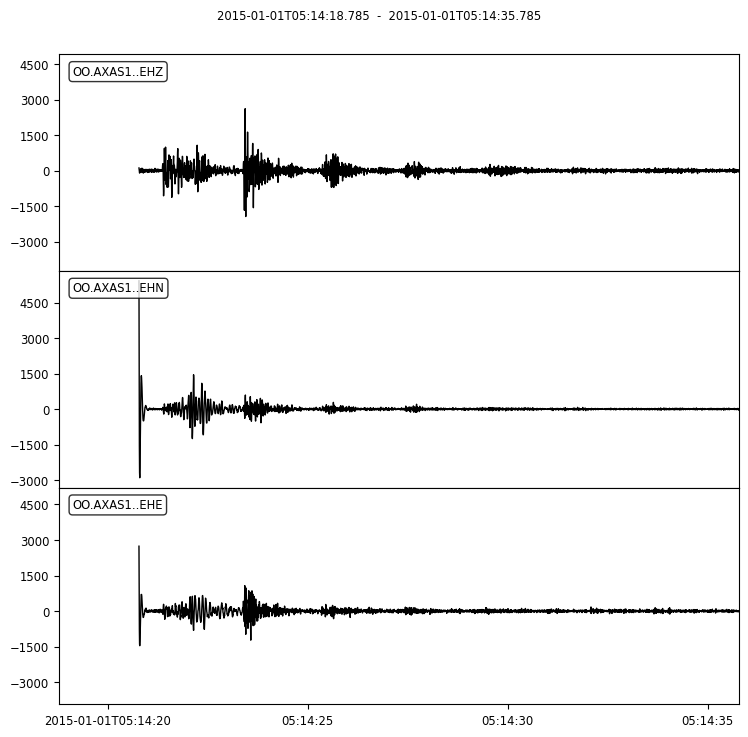

In [186]:
st_0.plot(title="Waveform for Earthquake 0 at AXAS1", ylabel="Amplitude", xlabel="Time (s)",
          starttime=st_0[0].stats.starttime -2, endtime=st_0[0].stats.starttime +15 )


plt.show()

In [187]:
sample_catalog['s_arrival'] = sample_catalog['datetime'].apply(
    lambda dt: UTCDateTime(dt)
) + sample_catalog['s_arrival_time']

In [188]:
sample_catalog

,id,year,datetime,lat,lon,depth,mag,time_diff_seconds,total_picks,p_arrival_time,...,s_weight,s_quality,station_id,station_lat,station_lon,station_elev,back_azimuth,angle_of_incidence,epicentral_distance_km,s_arrival
0,1015330,2015,2015-01-01 05:14:20.784,45.93734,-130.02082,1.205,0.8,0.016,2,0.57,...,1.0,EH,AXAS1,45.936,-130.013,-1.516,283.844437,12.892419,0.622813,2015-01-01T05:14:21.994000Z
1,1015330,2015,2015-01-01 05:14:20.784,45.93734,-130.02082,1.205,0.8,0.016,2,0.79,...,0.5,EH,AXID1,45.934,-130.004,-1.512,285.941436,26.467297,1.352710,2015-01-01T05:14:22.284000Z
2,1015346,2015,2015-01-01 09:15:46.225,45.94279,-130.01436,0.501,0.1,0.105,2,0.71,...,0.5,EH,AXAS1,45.936,-130.013,-1.516,352.070858,20.703522,0.762302,2015-01-01T09:15:47.615000Z
3,1015350,2015,2015-01-01 09:47:00.989,45.94051,-130.01304,0.462,0.1,0.149,2,0.69,...,0.5,EH,AXAS1,45.936,-130.013,-1.516,359.646623,14.226886,0.501499,2015-01-01T09:47:02.319000Z
4,1015355,2015,2015-01-01 10:17:29.103,45.96533,-129.98912,3.211,0.1,0.013,2,1.04,...,-0.5,EH,AXEC3,45.955,-129.973,-1.519,312.676632,19.711976,1.694701,2015-01-01T10:17:31.053000Z
5,1015378,2015,2015-01-01 13:52:20.310,45.94321,-130.02117,0.990,0.6,0.030,2,0.68,...,-0.2,EH,AXAS1,45.936,-130.013,-1.516,321.764479,22.161567,1.020719,2015-01-01T13:52:21.760000Z
6,1015403,2015,2015-01-01 18:21:18.160,45.94274,-130.01297,0.458,0.3,0.120,2,0.69,...,-0.5,EH,AXAS1,45.936,-130.013,-1.516,0.177338,20.789984,0.749457,2015-01-01T18:21:19.560000Z
7,1015419,2015,2015-01-01 20:45:19.203,45.96481,-129.98293,2.421,0.3,0.063,2,0.92,...,1.0,EH,AXEC3,45.955,-129.973,-1.519,324.870856,18.702590,1.333815,2015-01-01T20:45:20.943000Z
8,1015430,2015,2015-01-01 21:14:29.480,45.94512,-130.01336,0.314,0.2,0.100,2,0.78,...,1.0,EH,AXAS1,45.936,-130.013,-1.516,358.427745,29.002255,1.014480,2015-01-01T21:14:31.100000Z
9,1015437,2015,2015-01-01 21:19:39.413,45.97052,-129.99426,3.058,0.8,0.063,2,1.08,...,1.0,EH,AXEC3,45.955,-129.973,-1.519,316.409815,27.503338,2.382974,2015-01-01T21:19:41.503000Z


In [189]:
axas1 = sample_catalog['station_id'] == 'AXAS1'
axas1 = sample_catalog[axas1]

In [190]:
axas1

,id,year,datetime,lat,lon,depth,mag,time_diff_seconds,total_picks,p_arrival_time,...,s_weight,s_quality,station_id,station_lat,station_lon,station_elev,back_azimuth,angle_of_incidence,epicentral_distance_km,s_arrival
0,1015330,2015,2015-01-01 05:14:20.784,45.93734,-130.02082,1.205,0.8,0.016,2,0.57,...,1.0,EH,AXAS1,45.936,-130.013,-1.516,283.844437,12.892419,0.622813,2015-01-01T05:14:21.994000Z
2,1015346,2015,2015-01-01 09:15:46.225,45.94279,-130.01436,0.501,0.1,0.105,2,0.71,...,0.5,EH,AXAS1,45.936,-130.013,-1.516,352.070858,20.703522,0.762302,2015-01-01T09:15:47.615000Z
3,1015350,2015,2015-01-01 09:47:00.989,45.94051,-130.01304,0.462,0.1,0.149,2,0.69,...,0.5,EH,AXAS1,45.936,-130.013,-1.516,359.646623,14.226886,0.501499,2015-01-01T09:47:02.319000Z
5,1015378,2015,2015-01-01 13:52:20.310,45.94321,-130.02117,0.990,0.6,0.030,2,0.68,...,-0.2,EH,AXAS1,45.936,-130.013,-1.516,321.764479,22.161567,1.020719,2015-01-01T13:52:21.760000Z
6,1015403,2015,2015-01-01 18:21:18.160,45.94274,-130.01297,0.458,0.3,0.120,2,0.69,...,-0.5,EH,AXAS1,45.936,-130.013,-1.516,0.177338,20.789984,0.749457,2015-01-01T18:21:19.560000Z
8,1015430,2015,2015-01-01 21:14:29.480,45.94512,-130.01336,0.314,0.2,0.100,2,0.78,...,1.0,EH,AXAS1,45.936,-130.013,-1.516,358.427745,29.002255,1.014480,2015-01-01T21:14:31.100000Z
12,1015467,2015,2015-01-01 21:50:22.240,45.93636,-130.01982,1.171,-9.0,0.020,2,0.58,...,1.0,EH,AXAS1,45.936,-130.013,-1.516,274.342925,11.135920,0.528918,2015-01-01T21:50:23.440000Z


In [192]:
splitting_event = swspy.splitting.create_splitting_object(st_0, stations_in=[axas1['station_id'][0]], 
                                                          back_azis_all_stations=[axas1['back_azimuth'][0]], 
                                                          receiver_inc_angles_all_stations=[axas1['angle_of_incidence'][0]], 
                                                          S_phase_arrival_times=[axas1['s_arrival'][0]])

In [193]:
splitting_event.overall_win_start_pre_fast_S_pick = 0.3
splitting_event.win_S_pick_tolerance = 0.1
splitting_event.overall_win_start_post_fast_S_pick = 0.2 
splitting_event.rotate_step_deg = 1.0 
splitting_event.max_t_shift_s = 0.1 
splitting_event.n_win = 10

In [194]:
splitting_event.perform_sws_analysis(coord_system="ZNE", sws_method="EV_and_XC") #(coord_system="LQT") #(coord_system="ZNE")

,station,phi_from_Q,phi_from_N,phi_from_U,phi_err,dt,dt_err,src_pol_from_N,src_pol_from_U,src_pol_from_N_err,src_pol_from_U_err,Q_w,lambda2/lambda1 ratio,ray_back_azi,ray_inc
0,AXAS1,37.0,-39.155563,77.107581,14.5,0.09,0.01,116.900405,70.637441,27.089435,156.362345,0.0,0.071044,283.844437,12.892419


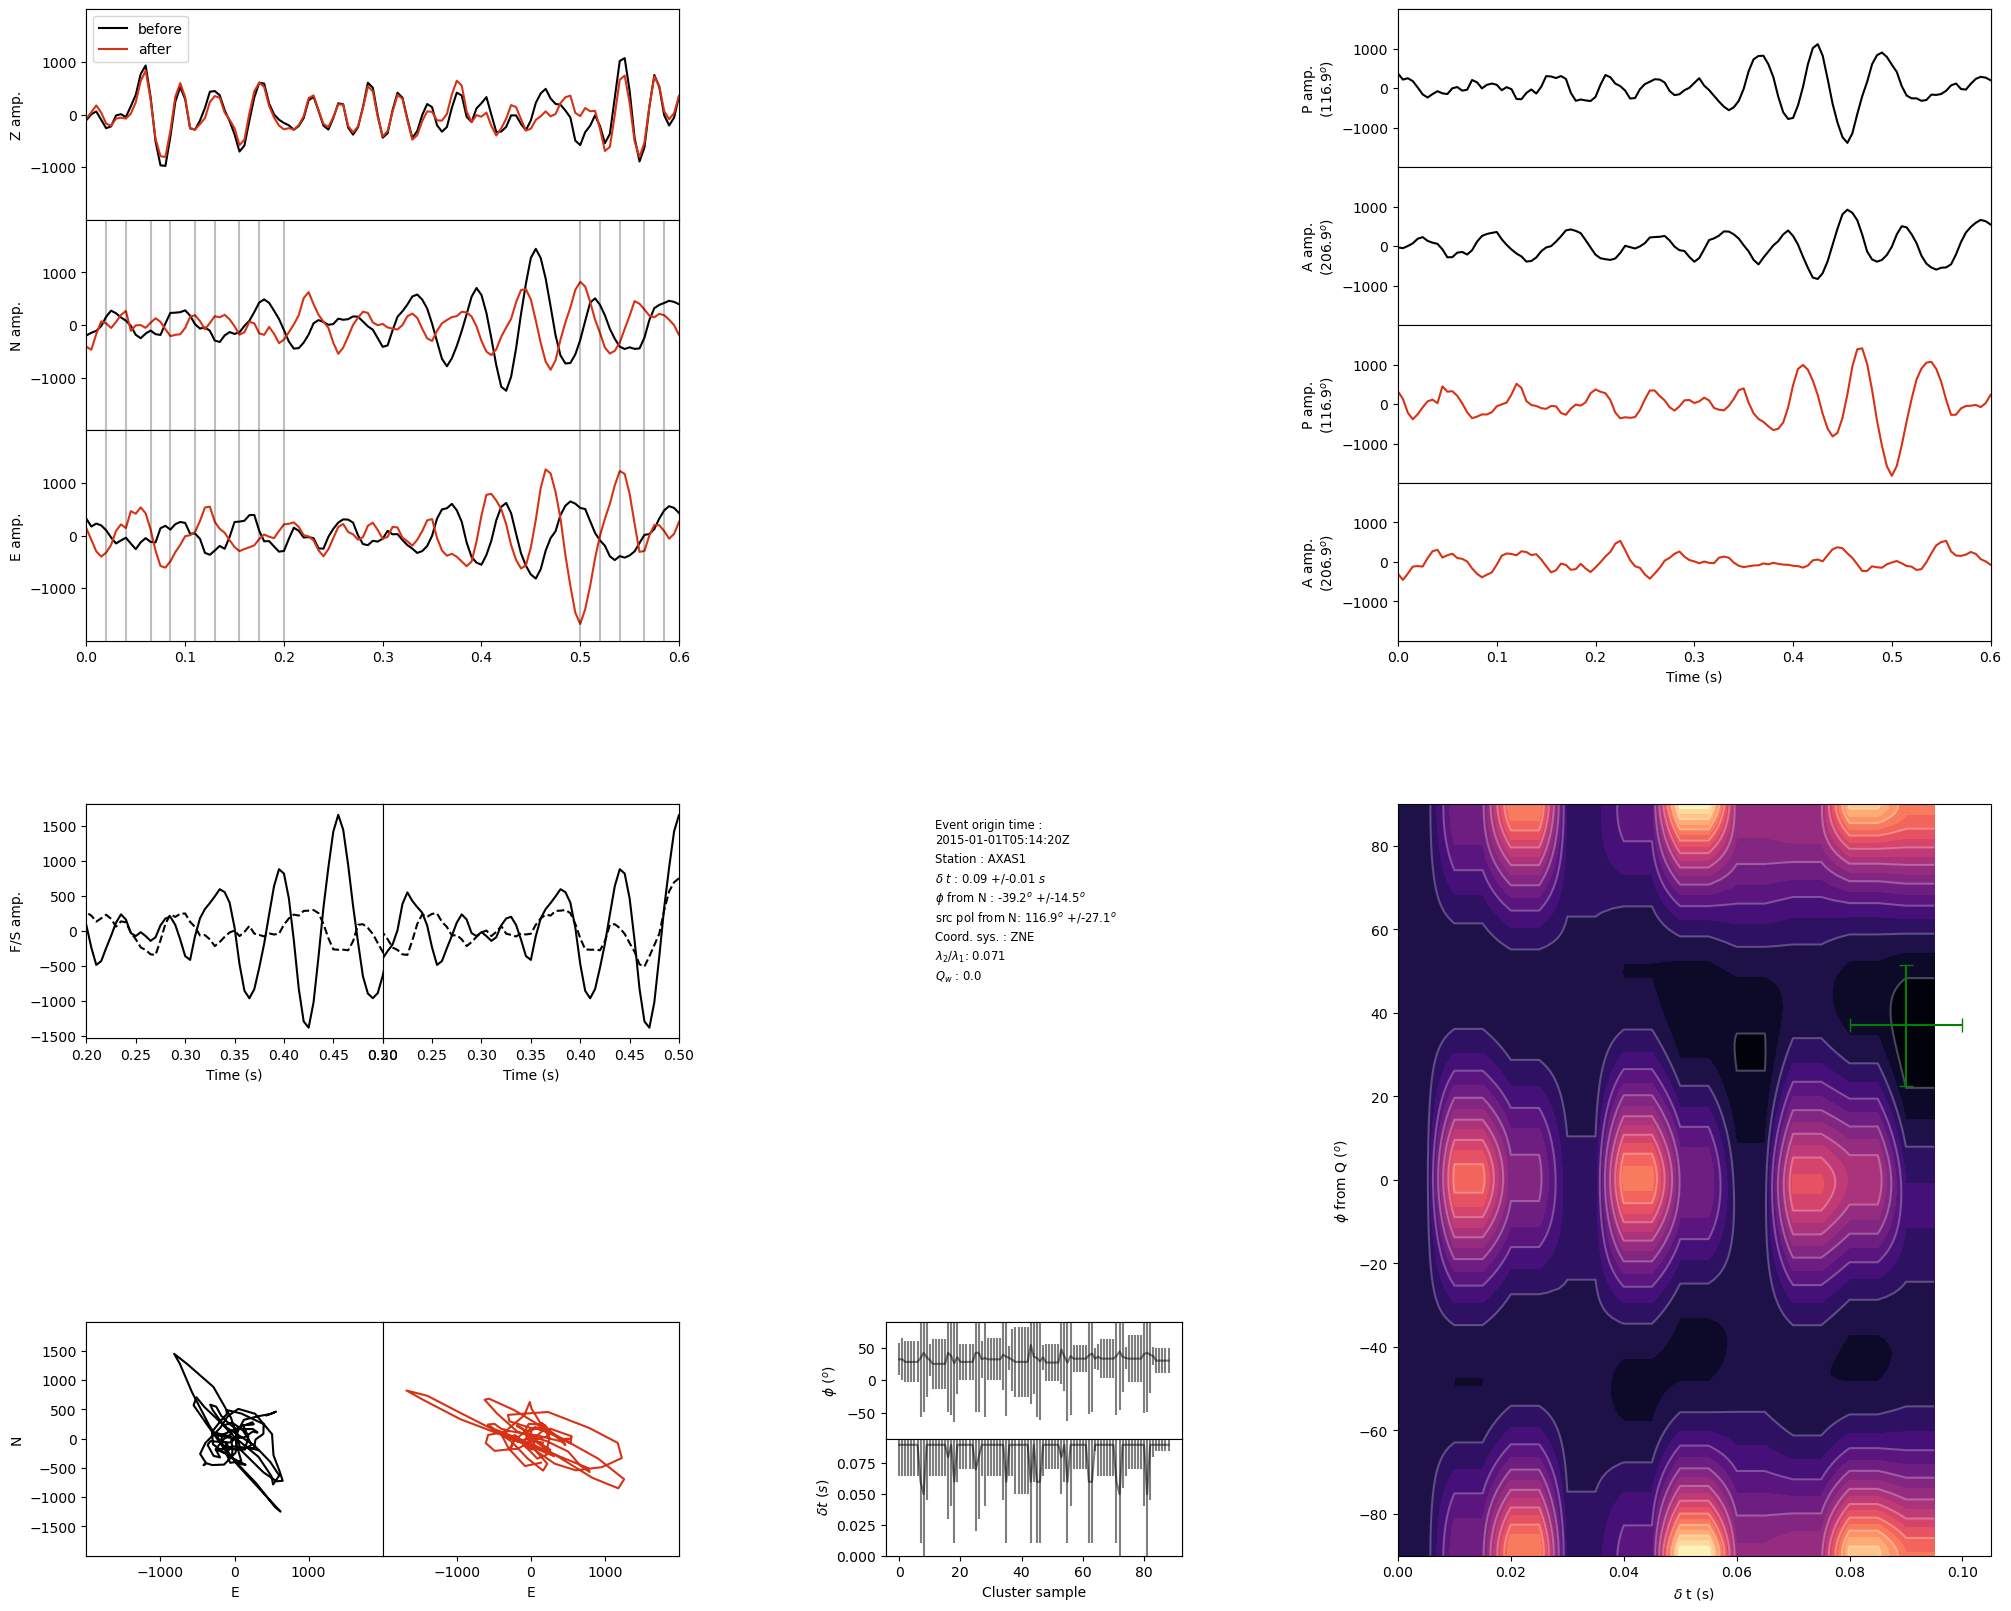

In [195]:
splitting_event.plot()

In [ ]:
## Toy example for rose plot parameters, Vs fast and Vs slow

# Extract splitting parameters from the analysis
print("=== SHEAR-WAVE SPLITTING RESULTS ===")

# Get the splitting parameters
fast_direction = 37.0 # Fast polarization direction (degrees)
delay_time = 0.09      # Delay time between fast and slow waves (seconds)

print(f"Fast polarization direction (φ): {fast_direction:.1f}°")
print(f"Delay time (δt): {delay_time:.3f} seconds")

# Calculate approximate velocities if we know the path length
# You can get epicentral distance from your catalog
epicentral_dist_km = axas1['epicentral_distance_km'].iloc[0]  # Use same index as waveform
earthquake_depth_km = axas1['depth'].iloc[0]

# Calculate approximate path length through anisotropic medium
# This is a simplified calculation - actual path depends on velocity structure
path_length_km = (epicentral_dist_km**2 + earthquake_depth_km**2)**0.5

print(f"\nPath parameters:")
print(f"Epicentral distance: {epicentral_dist_km:.1f} km")
print(f"Earthquake depth: {earthquake_depth_km:.1f} km") 
print(f"Approximate ray path length: {path_length_km:.1f} km")

# Calculate velocity difference (simplified)
# δt = L * (1/Vs_slow - 1/Vs_fast) where L is path length through anisotropic layer
# For rough estimates, assume anisotropic layer is ~20% of total path
anisotropic_layer_thickness = 0.2 * path_length_km  # Rough estimate

print(f"Estimated anisotropic layer thickness: {anisotropic_layer_thickness:.1f} km")

# If we assume typical S-wave velocities around 3.5-4.0 km/s and ~4% anisotropy
typical_vs = 3.7  # km/s - typical S-wave velocity
anisotropy_percent = 4.0  # percent

vs_fast = typical_vs * (1 + anisotropy_percent/200)  # Slightly faster
vs_slow = typical_vs * (1 - anisotropy_percent/200)  # Slightly slower

print(f"\nEstimated velocities (assuming {anisotropy_percent}% anisotropy):")
print(f"Fast S-wave velocity: {vs_fast:.2f} km/s")
print(f"Slow S-wave velocity: {vs_slow:.2f} km/s")
print(f"Velocity difference: {vs_fast - vs_slow:.3f} km/s")
print(f"Anisotropy percentage: {((vs_fast - vs_slow)/typical_vs)*100:.1f}%")

=== SHEAR-WAVE SPLITTING RESULTS ===
Fast polarization direction (φ): 37.0°
Delay time (δt): 0.090 seconds

Path parameters:
Epicentral distance: 0.6 km
Earthquake depth: 1.2 km
Approximate ray path length: 1.4 km
Estimated anisotropic layer thickness: 0.3 km

Estimated velocities (assuming 4.0% anisotropy):
Fast S-wave velocity: 3.77 km/s
Slow S-wave velocity: 3.63 km/s
Velocity difference: 0.148 km/s
Anisotropy percentage: 4.0%


In [166]:
st_1 = st.select(station='AXAS1')

In [167]:
st_1

30 Trace(s) in Stream:

OO.AXAS1..EHE | 2015-01-01T09:47:00.990000Z - 2015-01-01T09:47:15.985000Z | 200.0 Hz, 3000 samples
...
(28 other traces)
...
OO.AXAS1..EHZ | 2015-01-01T21:50:22.240000Z - 2015-01-01T21:50:37.240000Z | 200.0 Hz, 3001 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]

In [168]:
st_1 = st_1.trim(starttime=st_1[29].stats.starttime)


In [171]:
axas1

,id,year,datetime,lat,lon,depth,mag,time_diff_seconds,total_picks,p_arrival_time,...,s_weight,s_quality,station_id,station_lat,station_lon,station_elev,back_azimuth,angle_of_incidence,epicentral_distance_km,s_arrival
0,1015330,2015,2015-01-01 05:14:20.784,45.93734,-130.02082,1.205,0.8,0.016,2,0.57,...,1.0,EH,AXAS1,45.936,-130.013,-1.516,283.844437,12.892419,0.622813,2015-01-01T05:14:21.994000Z
1,1015330,2015,2015-01-01 05:14:20.784,45.93734,-130.02082,1.205,0.8,0.016,2,0.79,...,0.5,EH,AXAS1,45.934,-130.004,-1.512,285.941436,26.467297,1.352710,2015-01-01T05:14:22.284000Z
2,1015346,2015,2015-01-01 09:15:46.225,45.94279,-130.01436,0.501,0.1,0.105,2,0.71,...,0.5,EH,AXAS1,45.936,-130.013,-1.516,352.070858,20.703522,0.762302,2015-01-01T09:15:47.615000Z
3,1015350,2015,2015-01-01 09:47:00.989,45.94051,-130.01304,0.462,0.1,0.149,2,0.69,...,0.5,EH,AXAS1,45.936,-130.013,-1.516,359.646623,14.226886,0.501499,2015-01-01T09:47:02.319000Z
4,1015355,2015,2015-01-01 10:17:29.103,45.96533,-129.98912,3.211,0.1,0.013,2,1.04,...,-0.5,EH,AXAS1,45.955,-129.973,-1.519,312.676632,19.711976,1.694701,2015-01-01T10:17:31.053000Z
5,1015378,2015,2015-01-01 13:52:20.310,45.94321,-130.02117,0.990,0.6,0.030,2,0.68,...,-0.2,EH,AXAS1,45.936,-130.013,-1.516,321.764479,22.161567,1.020719,2015-01-01T13:52:21.760000Z
6,1015403,2015,2015-01-01 18:21:18.160,45.94274,-130.01297,0.458,0.3,0.120,2,0.69,...,-0.5,EH,AXAS1,45.936,-130.013,-1.516,0.177338,20.789984,0.749457,2015-01-01T18:21:19.560000Z
7,1015419,2015,2015-01-01 20:45:19.203,45.96481,-129.98293,2.421,0.3,0.063,2,0.92,...,1.0,EH,AXAS1,45.955,-129.973,-1.519,324.870856,18.702590,1.333815,2015-01-01T20:45:20.943000Z
8,1015430,2015,2015-01-01 21:14:29.480,45.94512,-130.01336,0.314,0.2,0.100,2,0.78,...,1.0,EH,AXAS1,45.936,-130.013,-1.516,358.427745,29.002255,1.014480,2015-01-01T21:14:31.100000Z
9,1015437,2015,2015-01-01 21:19:39.413,45.97052,-129.99426,3.058,0.8,0.063,2,1.08,...,1.0,EH,AXAS1,45.955,-129.973,-1.519,316.409815,27.503338,2.382974,2015-01-01T21:19:41.503000Z


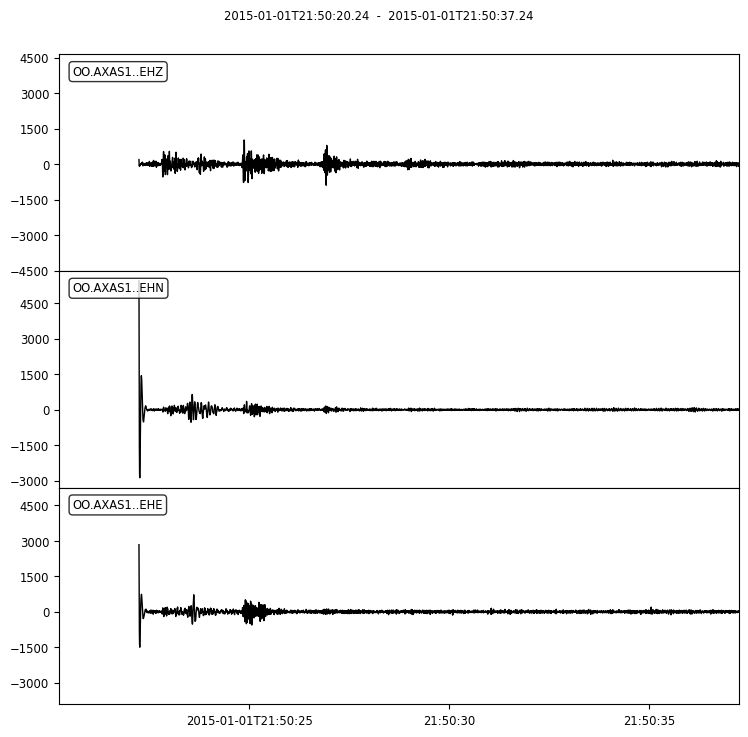

In [172]:
st_1.plot(title="Waveform for Earthquake 1 at AXIS1", ylabel="Amplitude", xlabel="Time (s)",
          starttime=st_1[0].stats.starttime -2, endtime=st_1[0].stats.starttime +15 )


plt.show()

In [175]:
splitting_event = swspy.splitting.create_splitting_object(st_1, stations_in=[axas1['station_id'][12]], 
                                                          back_azis_all_stations=[axas1['back_azimuth'][12]], 
                                                          receiver_inc_angles_all_stations=[axas1['angle_of_incidence'][12]], 
                                                          S_phase_arrival_times=[axas1['s_arrival'][12]])

In [176]:
splitting_event.overall_win_start_pre_fast_S_pick = 0.3
splitting_event.win_S_pick_tolerance = 0.1
splitting_event.overall_win_start_post_fast_S_pick = 0.2 
splitting_event.rotate_step_deg = 1.0 
splitting_event.max_t_shift_s = 0.1 
splitting_event.n_win = 10

In [177]:
splitting_event.perform_sws_analysis(coord_system="ZNE", sws_method="EV_and_XC") #(coord_system="LQT") #(coord_system="ZNE")

,station,phi_from_Q,phi_from_N,phi_from_U,phi_err,dt,dt_err,src_pol_from_N,src_pol_from_U,src_pol_from_N_err,src_pol_from_U_err,Q_w,lambda2/lambda1 ratio,ray_back_azi,ray_inc
0,AXAS1,40.0,-45.657075,78.86408,11.0,0.05,0.005,157.210426,93.751303,27.22631,139.313984,0.462516,0.066164,274.342925,11.13592


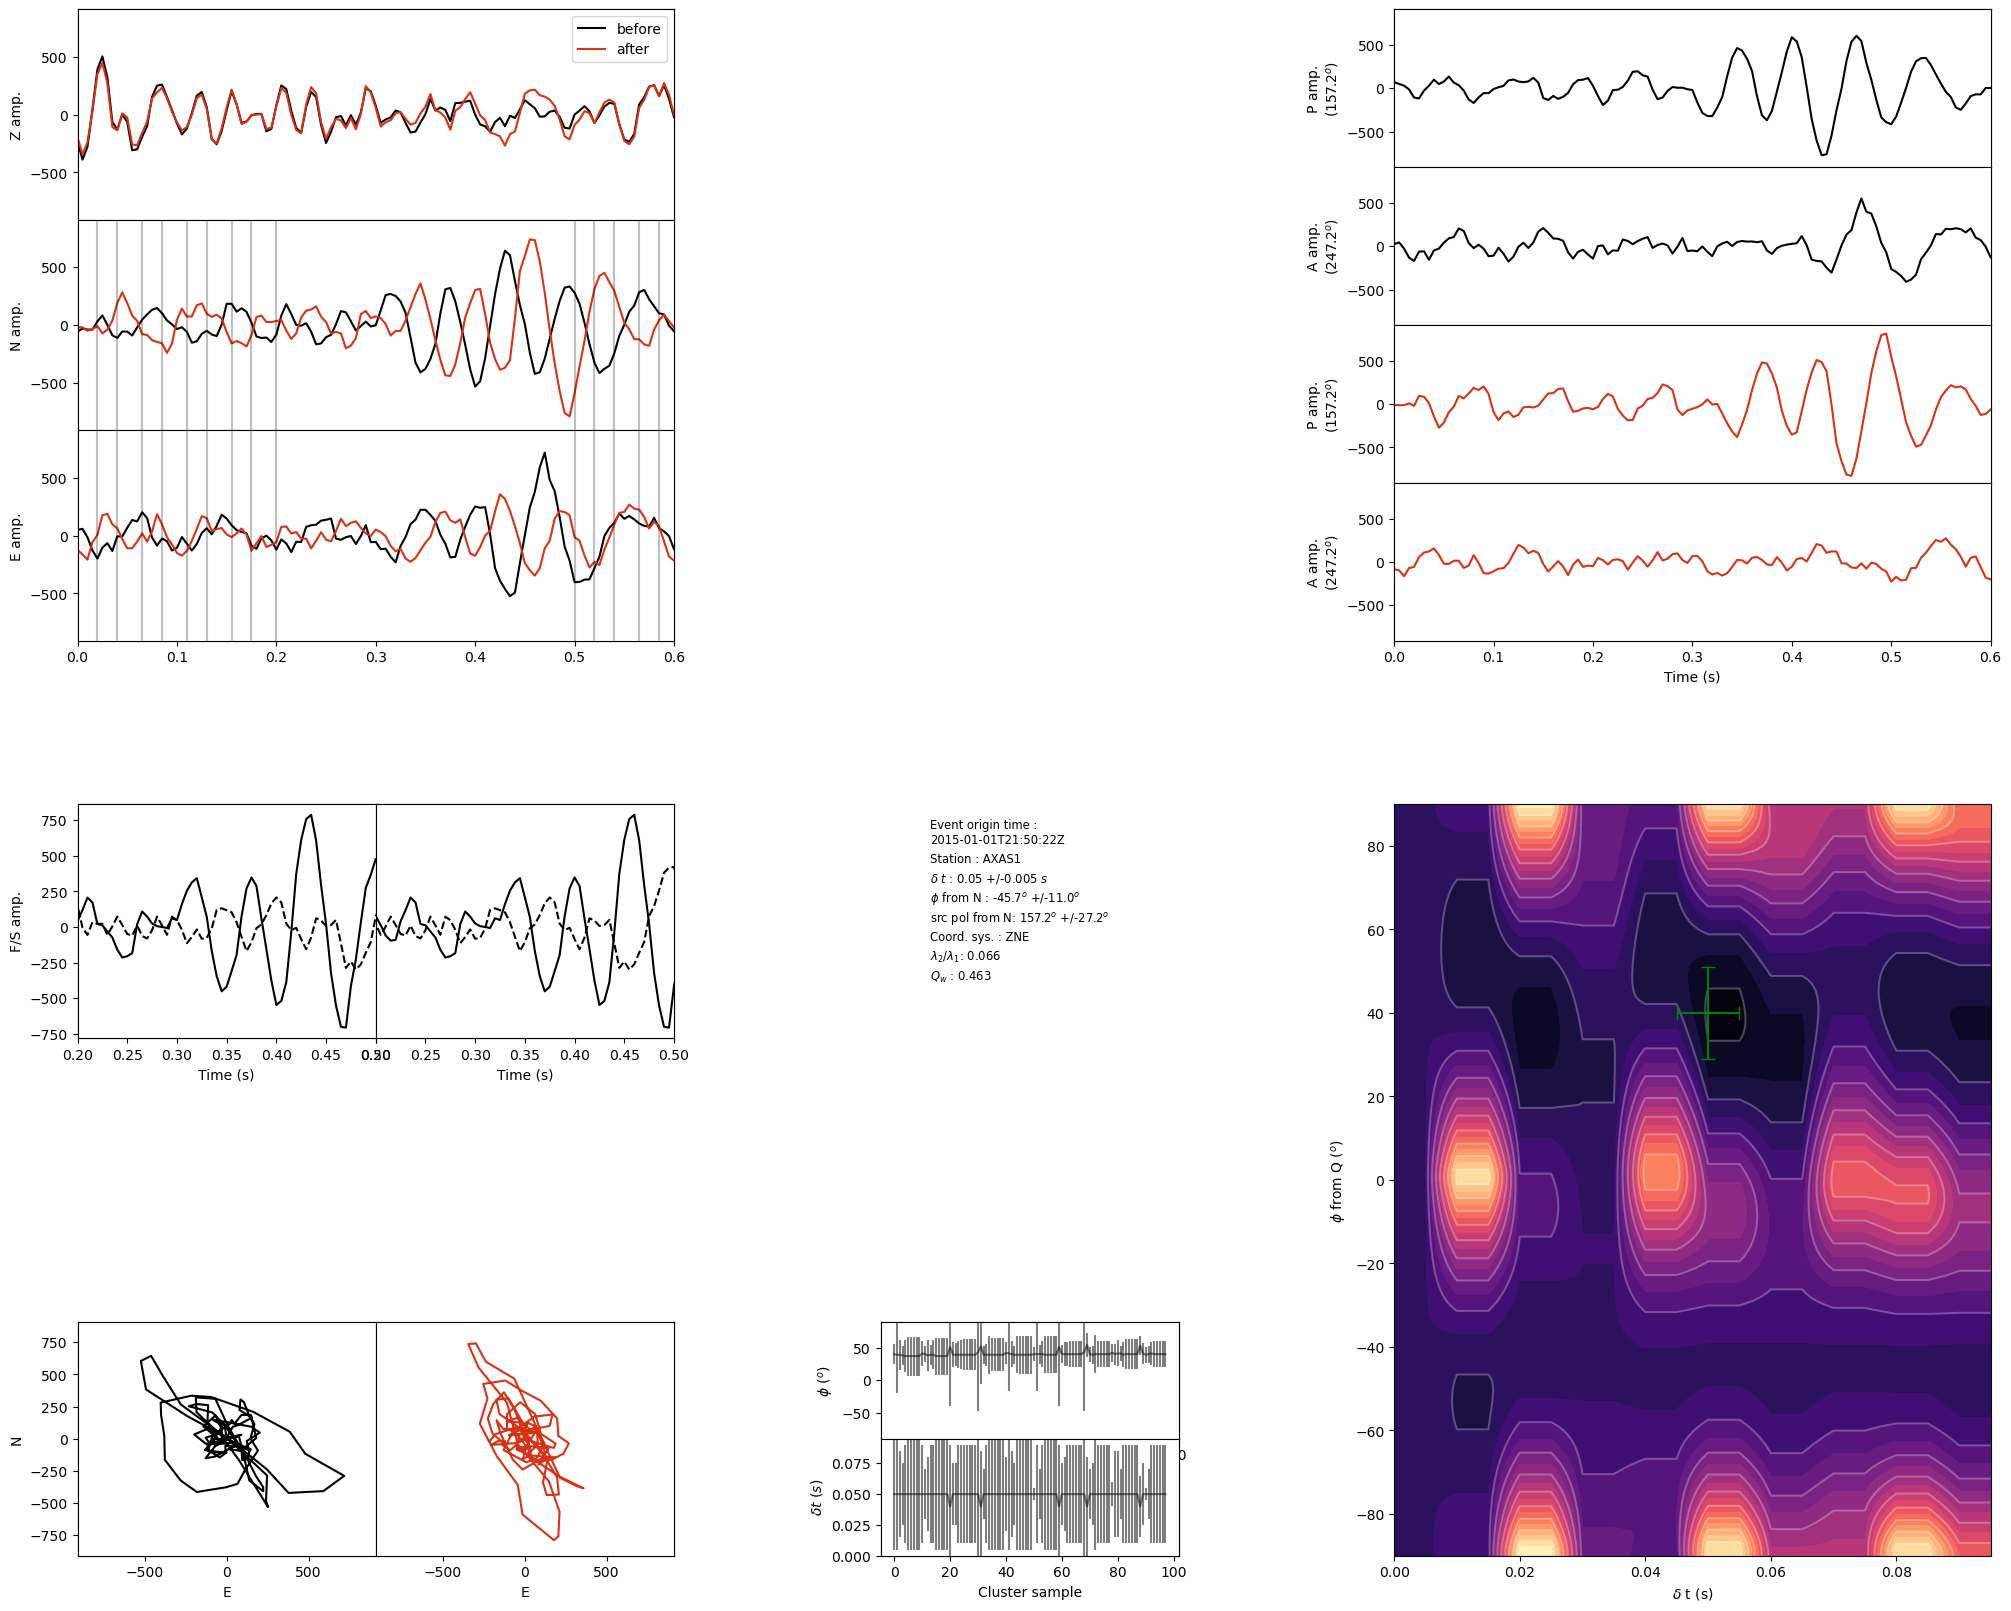

In [178]:
splitting_event.plot()